In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt


# Load the dataset
df = pd.read_csv("data/DS6021-Fall26-Anonymized.csv")

# Make a copy of the dataset so we can change it without affecting the original
clean_df = df.copy()


# Look at the dataset
"""
print(clean_df.shape)
clean_df.info()
clean_df.head()

# Check if there are any missing values in the dataset 
clean_df.isnull().sum()

# Save the original missing values for later use
original_missing_values = clean_df.isnull().sum()





# CHeck the different values in each column
for column in clean_df.columns:
    print(f"Column: {column}")
    print(clean_df[column].value_counts(dropna=False))
    print("\n") 
"""

df


,Timestamp,What was your undergraduate major?,What type of phone do you have?,How many years ago did you receive your undergraduate degree?,How many hours do you sleep in a typical night?,Rate your proficiency with git/github,Rate your proficiency with Python,Have you ever used SQL?,What is your favorite sport to watch on tv?,What is your ideal outdoor temperature (in Fahrenheit)?,How many US states have you visited?,What is your favorite season?
0,8/25/2026 8:20:43,Psychology,iPhone,4-6 years,8,3,2,Yes,F1 motorsport,70,8,Fall
1,8/25/2026 9:35:51,Statistics,iPhone,1-3 years,8,3,4,Yes,NaN,70,16,Fall
2,8/25/2026 13:43:23,Economics-Business and Applied Mathematics,iPhone,< 1 year,8,3,3,No,Baseball,70,27,Fall
3,8/25/2026 15:11:38,Data Science (concentration in Computer Science),iPhone,< 1 year,8,3,4,Yes,Football (go Bears!),73,9,Fall
4,8/25/2026 15:26:11,Math and Physics,iPhone,1-3 years,8,2,4,Yes,Figure Skating,73,26,Fall
...,...,...,...,...,...,...,...,...,...,...,...,...
81,8/26/2026 11:42:57,Bioinformatics and Biology,iPhone,< 1 year,5-7,2,3,No,Football,40 degrees,16,Winter
82,8/26/2026 11:44:34,Computer Science,iPhone,< 1 year,4 - 6,3,3,Yes,Soccer,75,1,Summer
83,8/26/2026 11:48:23,IT-Concentration in Data Science,iPhone,1-3 years,6.5,3,3,Yes,Soccer and Fustal,68,5,Spring
84,8/26/2026 11:52:24,Data Science,iPhone,< 1 year,7,4,4,No,Football,63,"If I had to guess, 23",Fall


### Cleaning and standardizing Columns 
After inspecting the raw data I have been given, I cleaned each column to make the values consistent and converted variables to the proper data types while keeping the original missing values. 

In [2]:
# Convert the Timestamp from text to datetime
clean_df['Timestamp'] = pd.to_datetime(clean_df['Timestamp']) 

# Check and verify the conversion
clean_df

,Timestamp,What was your undergraduate major?,What type of phone do you have?,How many years ago did you receive your undergraduate degree?,How many hours do you sleep in a typical night?,Rate your proficiency with git/github,Rate your proficiency with Python,Have you ever used SQL?,What is your favorite sport to watch on tv?,What is your ideal outdoor temperature (in Fahrenheit)?,How many US states have you visited?,What is your favorite season?
0,2026-08-25 08:20:43,Psychology,iPhone,4-6 years,8,3,2,Yes,F1 motorsport,70,8,Fall
1,2026-08-25 09:35:51,Statistics,iPhone,1-3 years,8,3,4,Yes,NaN,70,16,Fall
2,2026-08-25 13:43:23,Economics-Business and Applied Mathematics,iPhone,< 1 year,8,3,3,No,Baseball,70,27,Fall
3,2026-08-25 15:11:38,Data Science (concentration in Computer Science),iPhone,< 1 year,8,3,4,Yes,Football (go Bears!),73,9,Fall
4,2026-08-25 15:26:11,Math and Physics,iPhone,1-3 years,8,2,4,Yes,Figure Skating,73,26,Fall
...,...,...,...,...,...,...,...,...,...,...,...,...
81,2026-08-26 11:42:57,Bioinformatics and Biology,iPhone,< 1 year,5-7,2,3,No,Football,40 degrees,16,Winter
82,2026-08-26 11:44:34,Computer Science,iPhone,< 1 year,4 - 6,3,3,Yes,Soccer,75,1,Summer
83,2026-08-26 11:48:23,IT-Concentration in Data Science,iPhone,1-3 years,6.5,3,3,Yes,Soccer and Fustal,68,5,Spring
84,2026-08-26 11:52:24,Data Science,iPhone,< 1 year,7,4,4,No,Football,63,"If I had to guess, 23",Fall


## Timestamp 
Pandas orginally imported this column as an "object" because CSV files store the timestamp values as text. Since thede values represent data and times, I converted the column to a datatime date type using "pd.to_datetime()". 

In [3]:
# Inspect the undergraduate majors before cleaning 

clean_df["What was your undergraduate major?"].value_counts(dropna=False)



What was your undergraduate major?
Economics                                                               12
Computer Science                                                         7
Statistics                                                               6
Computer science                                                         4
Psychology                                                               3
Data Science                                                             3
Mechanical Engineering                                                   3
Business Administration                                                  1
Data Science/Econ                                                        1
Information Technology: Data Science and Analytics                       1
Statistics and Linguistics                                               1
Sports Management                                                        1
Math and Operations Research                                     

In [4]:
# Clean undergradute major 
clean_df["What was your undergraduate major?"] =( clean_df["What was your undergraduate major?"]
.str.strip()
.str.title()
)

# Verify the cleaned values 
clean_df["What was your undergraduate major?"].value_counts(dropna=False)


What was your undergraduate major?
Computer Science                                                        12
Economics                                                               12
Statistics                                                               6
Psychology                                                               3
Data Science                                                             3
Mechanical Engineering                                                   3
Intelligence Analysis                                                    1
Information Technology: Data Science And Analytics                       1
Statistics And Linguistics                                               1
Sports Management                                                        1
Math And Operations Research                                             1
Computer Science And Data Analytics                                      1
Accounting                                                       

### Undergraduate Major

I cleaned the undergraduate major column by removing extra spaces and making the capitalization consistent. This combined responses that meant the same thing, such as different versions of "Computer Science." I kept different majors separate so I would not change the original meaning of the responses.

In [5]:
# Convert phone type to category
clean_df["What type of phone do you have?"] = (
    clean_df["What type of phone do you have?"].astype("category")
)


### Phone Type

The phone responses were already consistent, so no values needed to be changed. I converted the column from object to category because it contains a small set of categories. The original missing value was kept.



In [6]:
# Inspect years since undergraduate degree
clean_df["How many years ago did you receive your undergraduate degree?"].value_counts(dropna=False)

How many years ago did you receive your undergraduate degree?
< 1 year      50
1-3 years     17
4-6 years     13
7-10 years     4
10+ years      2
Name: count, dtype: int64

In [7]:
# Convert years since undergraduate degree to an ordered category
year_order = [
    "< 1 year",
    "1-3 years",
    "4-6 years",
    "7-10 years",
    "10+ years"
]

degree_col = "How many years ago did you receive your undergraduate degree?"

clean_df[degree_col] = pd.Categorical(
    clean_df[degree_col],
    categories=year_order,
    ordered=True
)

clean_df.head(15)

,Timestamp,What was your undergraduate major?,What type of phone do you have?,How many years ago did you receive your undergraduate degree?,How many hours do you sleep in a typical night?,Rate your proficiency with git/github,Rate your proficiency with Python,Have you ever used SQL?,What is your favorite sport to watch on tv?,What is your ideal outdoor temperature (in Fahrenheit)?,How many US states have you visited?,What is your favorite season?
0,2026-08-25 08:20:43,Psychology,iPhone,4-6 years,8,3,2,Yes,F1 motorsport,70,8,Fall
1,2026-08-25 09:35:51,Statistics,iPhone,1-3 years,8,3,4,Yes,NaN,70,16,Fall
2,2026-08-25 13:43:23,Economics-Business And Applied Mathematics,iPhone,< 1 year,8,3,3,No,Baseball,70,27,Fall
3,2026-08-25 15:11:38,Data Science (Concentration In Computer Science),iPhone,< 1 year,8,3,4,Yes,Football (go Bears!),73,9,Fall
4,2026-08-25 15:26:11,Math And Physics,iPhone,1-3 years,8,2,4,Yes,Figure Skating,73,26,Fall
5,2026-08-25 20:43:55,Analytics,iPhone,< 1 year,7,1,3,Yes,Baseball,70 degrees,21,Spring
6,2026-08-26 10:10:40,Statistics,iPhone,< 1 year,7,4,4,Yes,Basketball,73,35-40,Summer
7,2026-08-26 10:11:02,Statistics And Media Studies,iPhone,< 1 year,6-7,2,3,No,None!,55,20,Winter
8,2026-08-26 10:11:07,Computer Science,iPhone,< 1 year,9,5,4,Yes,Football,64,16,Fall
9,2026-08-26 10:11:18,Economics,iPhone,< 1 year,5,4,3,Yes,College Hoops,70,7,Summer


In [8]:
clean_df['What is your ideal outdoor temperature (in Fahrenheit)?'] = clean_df['What is your ideal outdoor temperature (in Fahrenheit)?'].str.replace(r'[^\d.]', '', regex=True)
clean_df


,Timestamp,What was your undergraduate major?,What type of phone do you have?,How many years ago did you receive your undergraduate degree?,How many hours do you sleep in a typical night?,Rate your proficiency with git/github,Rate your proficiency with Python,Have you ever used SQL?,What is your favorite sport to watch on tv?,What is your ideal outdoor temperature (in Fahrenheit)?,How many US states have you visited?,What is your favorite season?
0,2026-08-25 08:20:43,Psychology,iPhone,4-6 years,8,3,2,Yes,F1 motorsport,70,8,Fall
1,2026-08-25 09:35:51,Statistics,iPhone,1-3 years,8,3,4,Yes,NaN,70,16,Fall
2,2026-08-25 13:43:23,Economics-Business And Applied Mathematics,iPhone,< 1 year,8,3,3,No,Baseball,70,27,Fall
3,2026-08-25 15:11:38,Data Science (Concentration In Computer Science),iPhone,< 1 year,8,3,4,Yes,Football (go Bears!),73,9,Fall
4,2026-08-25 15:26:11,Math And Physics,iPhone,1-3 years,8,2,4,Yes,Figure Skating,73,26,Fall
...,...,...,...,...,...,...,...,...,...,...,...,...
81,2026-08-26 11:42:57,Bioinformatics And Biology,iPhone,< 1 year,5-7,2,3,No,Football,40,16,Winter
82,2026-08-26 11:44:34,Computer Science,iPhone,< 1 year,4 - 6,3,3,Yes,Soccer,75,1,Summer
83,2026-08-26 11:48:23,It-Concentration In Data Science,iPhone,1-3 years,6.5,3,3,Yes,Soccer and Fustal,68,5,Spring
84,2026-08-26 11:52:24,Data Science,iPhone,< 1 year,7,4,4,No,Football,63,"If I had to guess, 23",Fall


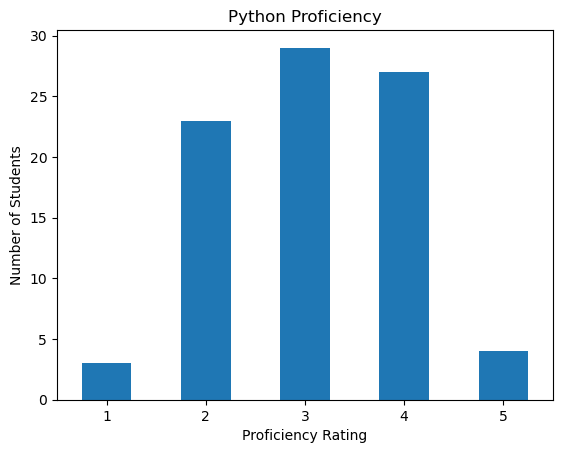

In [9]:
clean_df["Rate your proficiency with Python"].value_counts().sort_index().plot(kind="bar")

plt.title("Python Proficiency")
plt.xlabel("Proficiency Rating")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

**Observation:** 

Python proficiency varies across the students, with some proficiency levels being more common than others.

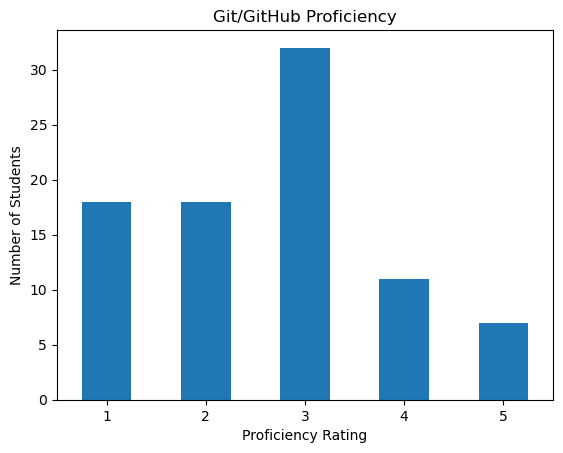

In [10]:
clean_df["Rate your proficiency with git/github"].value_counts().sort_index().plot(kind="bar")

plt.title("Git/GitHub Proficiency")
plt.xlabel("Proficiency Rating")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

**Observation:** 

Git/GitHub proficiency is spread across multiple skill levels, showing differences in students' experience with version control.

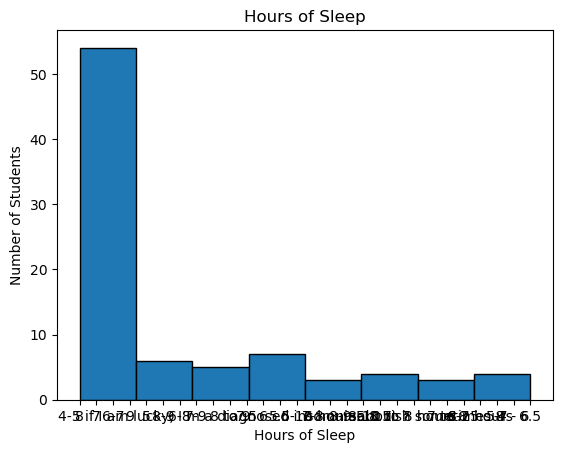

In [11]:
plt.hist(
    clean_df["How many hours do you sleep in a typical night?"].dropna(),
    bins=8,
    edgecolor="black"
)

plt.title("Hours of Sleep")

plt.xlabel("Hours of Sleep")

plt.ylabel("Number of Students")

plt.show()

**Observation:** 

The histogram shows how many hours of sleep students typically get each night and which sleep ranges are most common.

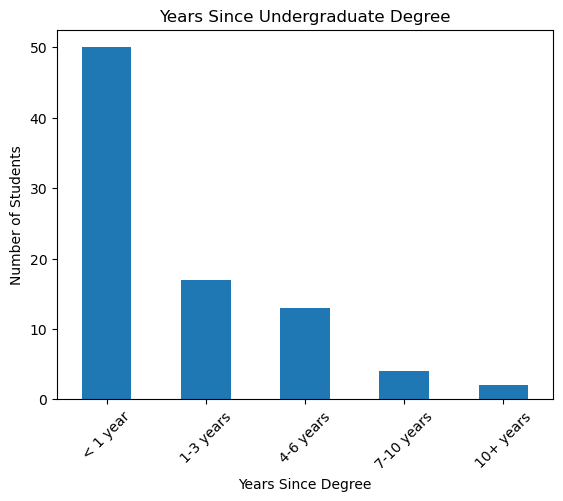

In [12]:
clean_df["How many years ago did you receive your undergraduate degree?"].value_counts(
    sort=False
).plot(kind="bar")

plt.title("Years Since Undergraduate Degree")

plt.xlabel("Years Since Degree")

plt.ylabel("Number of Students")

plt.xticks(rotation=45)

plt.show()

**Observation:** 

Most students received their undergraduate degree less than one year ago. The number of students decreases as the amount of time since graduation increases.

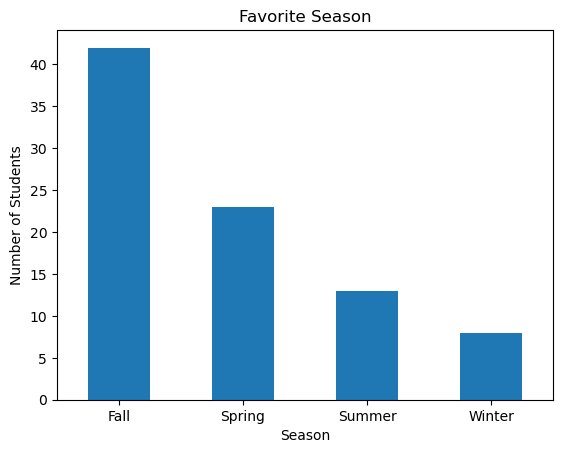

In [13]:
clean_df["What is your favorite season?"].value_counts().plot(kind="bar")

plt.title("Favorite Season")

plt.xlabel("Season")

plt.ylabel("Number of Students")

plt.xticks(rotation=0)

plt.show()

**Observation:** 

The bar chart shows how students in the dataset prefer different seasons.

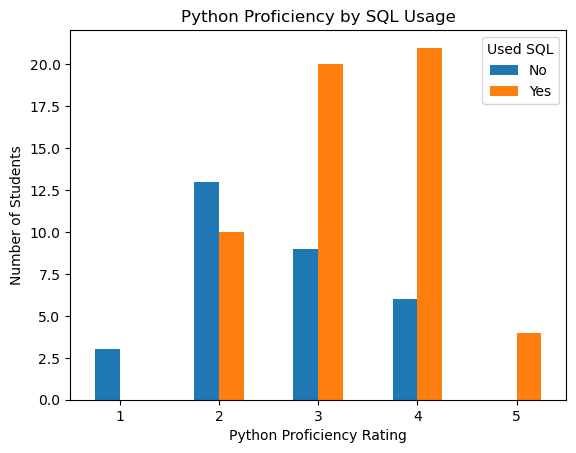

In [14]:
pd.crosstab(
    clean_df["Rate your proficiency with Python"],
    clean_df["Have you ever used SQL?"]
).plot(kind="bar")

plt.title("Python Proficiency by SQL Usage")

plt.xlabel("Python Proficiency Rating")

plt.ylabel("Number of Students")

plt.legend(title="Used SQL")

plt.xticks(rotation=0)

plt.show()

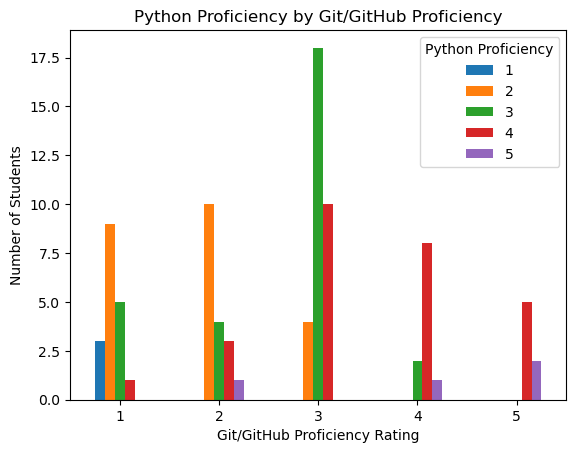

In [15]:
pd.crosstab(
    clean_df["Rate your proficiency with git/github"],
    clean_df["Rate your proficiency with Python"]
).plot(kind="bar")

plt.title("Python Proficiency by Git/GitHub Proficiency")

plt.xlabel("Git/GitHub Proficiency Rating")

plt.ylabel("Number of Students")

plt.legend(title="Python Proficiency")

plt.xticks(rotation=0)

plt.show()

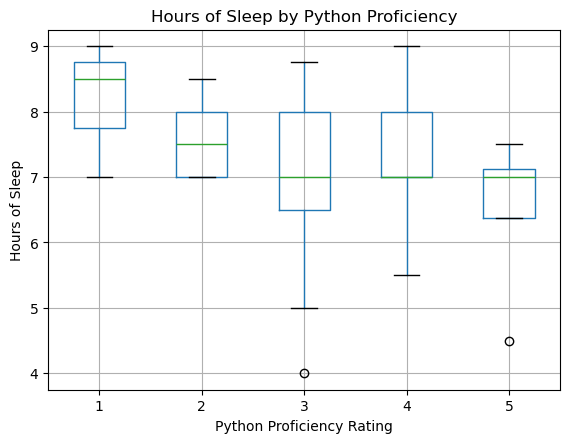

In [21]:
clean_df.boxplot(
    column="Sleep Hours Numeric",
    by="Rate your proficiency with Python"
)

plt.title("Hours of Sleep by Python Proficiency")

plt.suptitle("")

plt.xlabel("Python Proficiency Rating")

plt.ylabel("Hours of Sleep")

plt.show()

##  My reflections

### What surprised me about the dataset?

I was pretty surprised by how many different ways people answered questions that seemed simple. Like for example the questions about sleep, favorite sport, temperature, and states visited included exact answers, ranges, estimates, and written explanations. This showed me how inconsistent survey data can become when people are allowed to enter their own responses and its not a prompted multiple choice. 

### My cleaning choices

One choice I had to make was how to clean the hours of sleep column. Some people entered exact numbers, while others entered ranges or estimates like "6-7" or "7ish." I considered keeping all of the responses as text, but that would make it difficult to analyze and graph the data because its not consistent. 

Another choice involved the number of states visited. Some responses were exact numbers, while others were ranges, estimates, or descriptions. I considered converting every response into a number, but this would require me to guess what some people meant and that could change the data. I decided to keep these responses as text instead of creating numbers that were not actually provided by my classmates. 

### Python vs. Excel or Google Sheets

A problem with cleaning data in Excel or Google Sheets is that mistakes can be hard to track. Someone could accidentally delete or change data. Python saves the cleaning steps in the code, making the process easier to repeat and check.

## References 

When I received syntax errors I used ChatGPT (OpenAI) and Claude to help debug and fix errors in my Python code 